# Cell 1: Install required libraries

In [1]:
!pip install yfinance pandas numpy matplotlib seaborn plotly scikit-learn tensorflow

# Cell 2: Import libraries

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


# Cell 3: Download stock data

In [3]:
# You can change the stock ticker here (e.g., 'AAPL', 'GOOGL', 'MSFT', 'TSLA')
STOCK_TICKER = 'AAPL'
START_DATE = '2020-01-01'
END_DATE = '2026-01-01'

print(f"Downloading {STOCK_TICKER} stock data...")
df = yf.download(STOCK_TICKER, start=START_DATE, end=END_DATE)
print(f"Data shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nLast few rows:")
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Data shape: (1455, 5)

First few rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.538521  72.598899  71.292311  71.545897  135480400
2020-01-03  71.833298  72.594063  71.608692  71.765674  146322800
2020-01-06  72.405685  72.444328  70.703020  70.954195  118387200
2020-01-07  72.065163  72.671356  71.845385  72.415353  108872000
2020-01-08  73.224403  73.526295  71.768079  71.768079  132079200

Last few rows:
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-10-09  254.039993  258.000000  253.139999  257.809998  38322000
2025-10-10  245.270004  256.380005  244.000000  254.940002  61999100
2025-10-13  247.660004  249.690002  245.559998  249.380005  38142900
202

# Cell 5: Data preprocessing

In [4]:
# We'll use the 'Close' price for prediction
data = df['Close'].values.reshape(-1, 1)

# Split data into train and test sets (80-20 split)
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

print(f"Training data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

print("\nData normalized between 0 and 1")

Training data size: 1164
Testing data size: 291

Data normalized between 0 and 1


# Cell 6: Create sequences for LSTM

In [5]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Use 60 days of data to predict the next day
SEQ_LENGTH = 60

X_train, y_train = create_sequences(train_scaled, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQ_LENGTH)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1104, 60, 1)
y_train shape: (1104, 1)
X_test shape: (231, 60, 1)
y_test shape: (231, 1)


# Cell 7: Build LSTM model


In [6]:
model = Sequential([
    LSTM(units=150, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),

    LSTM(units=150, return_sequences=True),
    Dropout(0.2),

    LSTM(units=150),
    Dropout(0.2),

    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 150)        │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 150)        │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 452,551 (1.73 MB)

 Trainable params: 452,551 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

None


# Cell 8: Train the model


In [7]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training the model... This may take a few minutes.")
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=100,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining completed!")

Training the model... This may take a few minutes.
Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - loss: 0.0685 - val_loss: 0.0180
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0065 - val_loss: 0.0227
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0041 - val_loss: 0.0125
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0033 - val_loss: 0.0088
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0027 - val_loss: 0.0051
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0023 - val_loss: 0.0029
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0021 - val_loss: 0.0028
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0022 - val_loss: 0.0032
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.0021 - val_loss: 0.0023
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.0021 - val_loss: 0.0036


# Cell 10: Make predictions


In [8]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Inverse transform to get actual prices
train_predictions = scaler.inverse_transform(train_predictions)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predictions = scaler.inverse_transform(test_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predictions completed!")

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Predictions completed!


# Cell 11: Evaluate model performance


In [9]:
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predictions))
train_mae = mean_absolute_error(y_train_actual, train_predictions)
train_r2 = r2_score(y_train_actual, train_predictions)

test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predictions))
test_mae = mean_absolute_error(y_test_actual, test_predictions)
test_r2 = r2_score(y_test_actual, test_predictions)

print("="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print("\nTraining Set:")
print(f"  RMSE: ${train_rmse:.2f}")
print(f"  MAE:  ${train_mae:.2f}")
print(f"  R²:   {train_r2:.4f}")

print("\nTesting Set:")
print(f"  RMSE: ${test_rmse:.2f}")
print(f"  MAE:  ${test_mae:.2f}")
print(f"  R²:   {test_r2:.4f}")
print("="*60)

MODEL PERFORMANCE METRICS

Training Set:
  RMSE: $4.31
  MAE:  $3.29
  R²:   0.9831

Testing Set:
  RMSE: $7.00
  MAE:  $4.92
  R²:   0.8632


# Cell 12: Visualize predictions


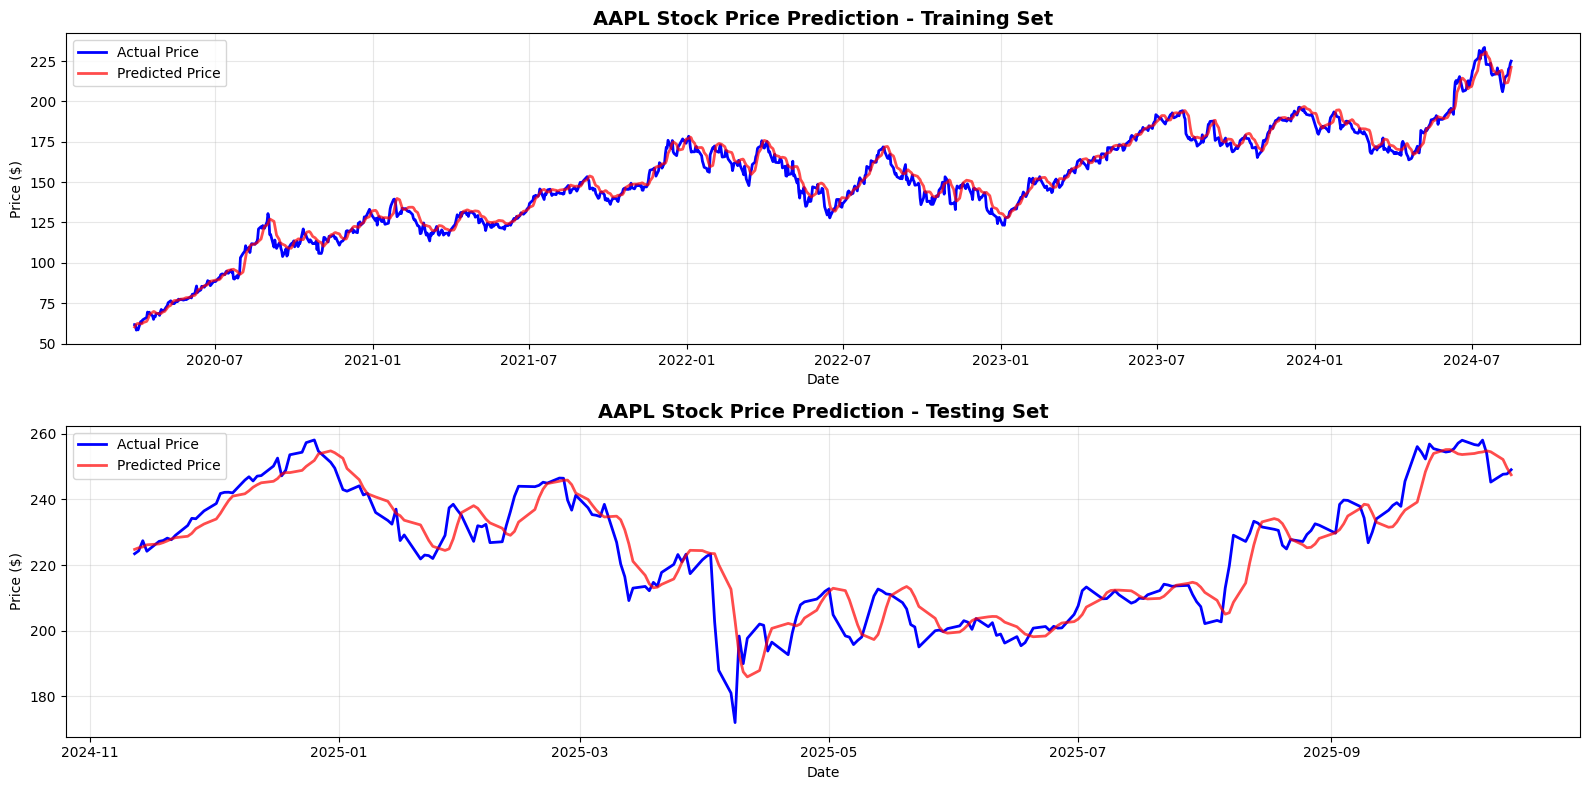

In [10]:
plt.figure(figsize=(16, 8))

# Training predictions
train_dates = df.index[SEQ_LENGTH:train_size]
plt.subplot(2, 1, 1)
plt.plot(train_dates, y_train_actual, label='Actual Price', color='blue', linewidth=2)
plt.plot(train_dates, train_predictions, label='Predicted Price', color='red', linewidth=2, alpha=0.7)
plt.title(f'{STOCK_TICKER} Stock Price Prediction - Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Testing predictions
test_dates = df.index[train_size+SEQ_LENGTH:]
plt.subplot(2, 1, 2)
plt.plot(test_dates, y_test_actual, label='Actual Price', color='blue', linewidth=2)
plt.plot(test_dates, test_predictions, label='Predicted Price', color='red', linewidth=2, alpha=0.7)
plt.title(f'{STOCK_TICKER} Stock Price Prediction - Testing Set', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cell 13: Predict future prices (next 30 days)


In [11]:
last_sequence = test_scaled[-SEQ_LENGTH:].reshape(1, SEQ_LENGTH, 1)
future_predictions = []

print(f"Predicting next 30 days for {STOCK_TICKER}...")

for _ in range(30):
    next_pred = model.predict(last_sequence, verbose=0)
    future_predictions.append(next_pred[0, 0])

    # Update sequence
    last_sequence = np.append(last_sequence[:, 1:, :], next_pred.reshape(1, 1, 1), axis=1)

# Inverse transform predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='B')

print("Future predictions completed!")

Predicting next 30 days for AAPL...
Future predictions completed!


# Cell 14: Visualize future predictions


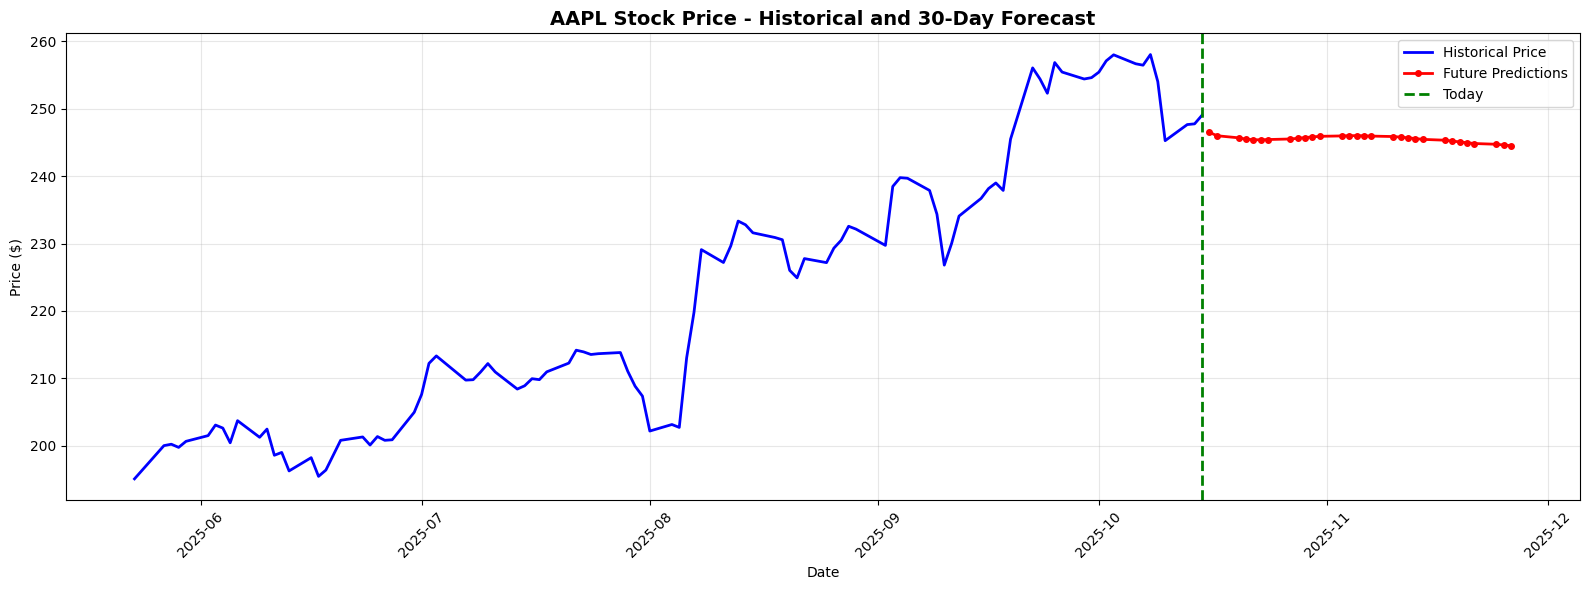

In [12]:
plt.figure(figsize=(16, 6))

# Plot historical data
plt.plot(df.index[-100:], df['Close'].values[-100:],
         label='Historical Price', color='blue', linewidth=2)

# Plot future predictions
plt.plot(future_dates, future_predictions,
         label='Future Predictions', color='red', linewidth=2, marker='o', markersize=4)

plt.axvline(x=df.index[-1], color='green', linestyle='--', linewidth=2, label='Today')
plt.title(f'{STOCK_TICKER} Stock Price - Historical and 30-Day Forecast',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cell 15: Display future predictions table


In [13]:
future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Price': future_predictions.flatten()
})
future_df['Date'] = future_df['Date'].dt.strftime('%Y-%m-%d')

print("\n" + "="*60)
print(f"FUTURE PRICE PREDICTIONS FOR {STOCK_TICKER} (Next 30 Days)")
print("="*60)
print(future_df.to_string(index=False))
print("="*60)

# Calculate trend
first_pred = future_predictions[0][0]
last_pred = future_predictions[-1][0]
change = last_pred - first_pred
change_pct = (change / first_pred) * 100

up = "📈"
down = "📉"
print(f"\nPredicted 30-day trend: {up if change > 0 else down} {'UP' if change > 0 else 'DOWN'}")
print(f"Expected change: ${change:.2f} ({change_pct:+.2f}%)")
print("="*60)

print("\n✅ Analysis complete! You can modify STOCK_TICKER in Cell 3 to analyze different stocks.")


FUTURE PRICE PREDICTIONS FOR AAPL (Next 30 Days)
      Date  Predicted Price
2025-10-16       246.534454
2025-10-17       246.007874
2025-10-20       245.691055
2025-10-21       245.502762
2025-10-22       245.411163
2025-10-23       245.396423
2025-10-24       245.439438
2025-10-27       245.521042
2025-10-28       245.623337
2025-10-29       245.730804
2025-10-30       245.830933
2025-10-31       245.914581
2025-11-03       245.975342
2025-11-04       246.009827
2025-11-05       246.016693
2025-11-06       245.996506
2025-11-07       245.951126
2025-11-10       245.883560
2025-11-11       245.797256
2025-11-12       245.696045
2025-11-13       245.583725
2025-11-14       245.463867
2025-11-17       245.339691
2025-11-18       245.214005
2025-11-19       245.089157
2025-11-20       244.967056
2025-11-21       244.848862
2025-11-24       244.735519
2025-11-25       244.627487
2025-11-26       244.525024

Predicted 30-day trend: 📉 DOWN
Expected change: $-2.01 (-0.82%)

✅ Analysis compl